In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os
from matplotlib.colors import LinearSegmentedColormap

# 颜色
c = 'coral'
c1 = 'yellowgreen'
base_c = 'aqua'

# 坐标轴刻度大小（和Beta_Collocation_points_plots.ipynb一致）
ticks_fontsize = 10

# XY轴标签字体大小（和Beta_Collocation_points_plots.ipynb一致）
label_fontsize = 14

# 动态colorbar格式化函数
def format_colorbar_tick(x, p):
    """
    动态设置colorbar刻度的小数点位数
    绝对值<1: 3位; 1<=绝对值<10: 2位; 10<=绝对值<100: 1位; 绝对值>=100: 0位
    """
    abs_x = abs(x)
    if abs_x < 1:
        return f'{x:.3f}'
    elif abs_x < 10:
        return f'{x:.2f}'
    elif abs_x < 100:
        return f'{x:.1f}'
    else:
        return f'{x:.0f}'

def truncated_cmap(cmap_name, minval=0.0, maxval=1.0, n=256):
    """Return a copy of cmap_name trimmed to [minval, maxval] to soften extremes."""
    cmap = plt.get_cmap(cmap_name)
    colors = cmap(np.linspace(minval, maxval, n))
    return LinearSegmentedColormap.from_list(f"{cmap_name}_trunc", colors)

### sys-1

### Different Datanumber

In [3]:
import re
import numpy as np

k_ranges = [[1.0, 2.5], [2.5, 5.0], [5.0, 10.0], [10.0, 20.0], [20.0, 30.0], [30.0, 50.0], [50.0, 100.0], [100.0, 200.0]]
lr_range = [0.001] 
sub_sampling_range = [256, 128, 64, 32, 16, 8 ,4, 2]   ##4096, 2048, 1024, 512, 
data_number_range = ['128','256', '512', '1024', '2048', '4096', '8192', '16384']   ###'8', '16', '32', '64',  
seed_range = [2021, 2022, 2023, 2024, 2025] #2020, 2021, 2022, 

bsz = 128


exp_type = 'train'

In [4]:
k_range_list = []
for k_range in k_ranges:
        # 修改成小数点之后如果是 .0可以忽略
        def format_num(x):
            return str(int(x)) if x == int(x) else str(x)
        k_range_list.append(f'{format_num(k_range[0])}-')

In [5]:
exp_stats = {}

In [6]:
for k_range in k_ranges:
    pde_settings = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    exp_stats[pde_settings] = {}
    
    for subsamples in sub_sampling_range:
        for lr in lr_range:

            hyper_settings = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
            
            exp_stats[pde_settings][hyper_settings] = {}
            best_test_err_by_seed = []
            best_train_err_by_seed = []
            ### average over seeds
            for seed in seed_range:
                hyper_settings_tmp = f'{hyper_settings}/seed{seed}'
                if subsamples == 256:
                    base_dir = '/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/results_sameiteration/expts_eps1000'
                elif subsamples == 128:
                    base_dir = '/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/results_sameiteration/expts_eps750'
                elif subsamples == 64:
                    base_dir = '/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/results_sameiteration/expts_eps500'
                elif subsamples == 32:
                    base_dir = '/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/results_sameiteration/expts_eps300'
                elif subsamples == 16:
                    base_dir = '/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/results_sameiteration/expts_eps200'
                elif subsamples == 8:
                    base_dir = '/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/results_sameiteration/expts_eps150'
                elif subsamples == 4:
                    base_dir = '/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/results_sameiteration/expts_eps100'
                elif subsamples == 2:
                    base_dir = '/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/results_sameiteration/expts_eps75'
                    
                    
                    
                best_log = f'{base_dir}/{pde_settings}/{exp_type}/{hyper_settings_tmp}/logs.txt'
                
                if subsamples == 256:
                    stop_epoch = 999
                elif subsamples == 128:
                    stop_epoch = 749
                elif subsamples == 64:
                    stop_epoch = 499    
                elif subsamples == 32:
                    stop_epoch = 299
                elif subsamples == 16:
                    stop_epoch = 199
                elif subsamples == 8:
                    stop_epoch = 149
                elif subsamples == 4:
                    stop_epoch = 99
                elif subsamples == 2:
                    stop_epoch = 74
                else:
                    stop_epoch = 999
                    
       
                    
                ## read the txt
                test_err = 1e999
                train_err = 1e999
                try:
                    with open(best_log, 'r') as f:
                        lines = f.readlines()
                        for line in lines:
                            if 'best_val_err' in line:
                                test_err = float(re.search(r"tensor\(\[([0-9.]+)\]", line).group(1))
                            elif 'tr_err' in line:
                                train_err = float(re.search(r"tensor\(\[([0-9.]+)\]", line).group(1))
                            
                            if f'epoch,{stop_epoch}' in line:
                                break
                    
                    best_test_err_by_seed.append(test_err)
                    best_train_err_by_seed.append(train_err)
                except Exception as e:
                    print(f'Error reading {best_log}: {e}')
                
            #print(f'{pde_settings} {hyper_settings} {np.mean(best_test_err_by_seed)}')
            exp_stats[pde_settings][hyper_settings]['test_err_mean'] = np.mean(best_test_err_by_seed)
            exp_stats[pde_settings][hyper_settings]['test_err_std'] = np.std(best_test_err_by_seed)
            exp_stats[pde_settings][hyper_settings]['train_err_mean'] = np.mean(best_train_err_by_seed)
            exp_stats[pde_settings][hyper_settings]['train_err_std'] = np.std(best_train_err_by_seed)

(8, 8)


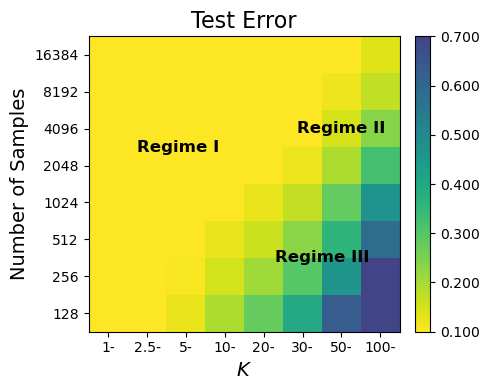

In [42]:
### 8 \times 8 grid - Test Error
import numpy as np
import matplotlib.pyplot as plt

pde_settings = k_range_list
lr = lr_range[0]
## 8x8 array
loss = np.array([[0.0 for _ in range(len(pde_settings))] for _ in range(len(sub_sampling_range))])
print(loss.shape)

for k_range in k_ranges:
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    for subsamples in sub_sampling_range:
        if subsamples == 512:
            hyper_setting = f'bsz64_lr{lr}_subsample{subsamples}'
        elif subsamples == 1024:
            hyper_setting = f'bsz32_lr{lr}_subsample{subsamples}'
        elif subsamples == 2048:
            hyper_setting = f'bsz16_lr{lr}_subsample{subsamples}'
        elif subsamples == 4096:
            hyper_setting = f'bsz8_lr{lr}_subsample{subsamples}'
        else:
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        loss[sub_sampling_range.index(subsamples), k_ranges.index(k_range)] = exp_stats[pde_setting][hyper_setting]['test_err_mean']

fig, ax = plt.subplots(1, 1, figsize=(5, 4))

X, Y = np.meshgrid(np.arange(len(pde_settings)), np.arange(len(sub_sampling_range)))
soft_seismic = truncated_cmap("viridis_r", minval=0.0, maxval=0.8)
heatmap = ax.pcolormesh(X, Y, loss, cmap=soft_seismic, shading='auto', rasterized=True, vmin=0.1, vmax=0.7)

ax.set_xticks(np.arange(len(pde_settings)))
ax.set_xticklabels(pde_settings, fontsize=ticks_fontsize)
ax.set_yticks(np.arange(len(sub_sampling_range)))
ax.set_yticklabels(data_number_range, fontsize=ticks_fontsize)

ax.set_xlabel("$K$", fontsize=label_fontsize)
ax.set_ylabel("Number of Samples", fontsize=label_fontsize)
ax.set_title("Test Error", fontsize=16)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(heatmap, cax=cax)
cbar.ax.tick_params(labelsize=ticks_fontsize)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(format_colorbar_tick))


ax.text(x=1.8, y=4.5, s="Regime I", ha='center', va='center', fontsize=12, fontweight="bold", color="black")
ax.text(x=5.5, y=1.5, s="Regime III", ha='center', va='center', fontsize=12, fontweight="bold", color="black")
ax.text(x=6.0, y=5.0, s="Regime II", ha='center', va='center', fontsize=12, fontweight="bold", color="black")


plt.tight_layout()
plt.savefig('/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/plots/pdf/test_error_fno.pdf', bbox_inches='tight')
plt.show()

(8, 8)


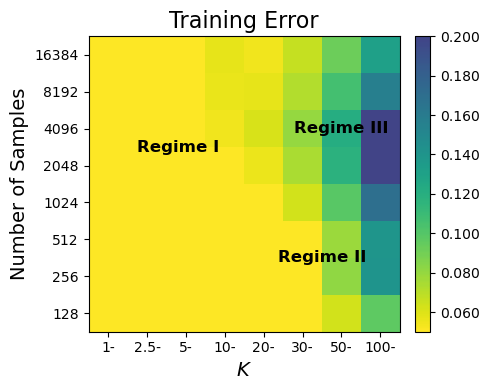

In [ ]:
### 8 \times 8 grid - Training Error
import numpy as np
import matplotlib.pyplot as plt

pde_settings = k_range_list
lr = lr_range[0]
## 8x8 array
loss = np.array([[0.0 for _ in range(len(pde_settings))] for _ in range(len(sub_sampling_range))])
print(loss.shape)

for k_range in k_ranges:
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    for subsamples in sub_sampling_range:
        if subsamples == 512:
            hyper_setting = f'bsz64_lr{lr}_subsample{subsamples}'
        elif subsamples == 1024:
            hyper_setting = f'bsz32_lr{lr}_subsample{subsamples}'
        elif subsamples == 2048:
            hyper_setting = f'bsz16_lr{lr}_subsample{subsamples}'
        elif subsamples == 4096:
            hyper_setting = f'bsz8_lr{lr}_subsample{subsamples}'
        else:
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        loss[sub_sampling_range.index(subsamples), k_ranges.index(k_range)] = exp_stats[pde_setting][hyper_setting]['train_err_mean']

fig, ax = plt.subplots(1, 1, figsize=(5, 4))

X, Y = np.meshgrid(np.arange(len(pde_settings)), np.arange(len(sub_sampling_range)))
heatmap = ax.pcolormesh(X, Y, loss, cmap=soft_seismic, shading='auto', rasterized=True,  vmin=0.05, vmax=0.2)

ax.set_xticks(np.arange(len(pde_settings)))
ax.set_xticklabels(pde_settings, fontsize=ticks_fontsize)
ax.set_yticks(np.arange(len(sub_sampling_range)))
ax.set_yticklabels(data_number_range, fontsize=ticks_fontsize)

ax.set_xlabel("$K$", fontsize=label_fontsize)
ax.set_ylabel("Number of Samples", fontsize=label_fontsize)
ax.set_title("Training Error", fontsize=16)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(heatmap, cax=cax)
cbar.ax.tick_params(labelsize=ticks_fontsize)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(format_colorbar_tick))

ax.text(x=1.8, y=4.5, s="Regime I", ha='center', va='center', fontsize=12, fontweight="bold", color="black")
ax.text(x=5.5, y=1.5, s="Regime III", ha='center', va='center', fontsize=12, fontweight="bold", color="black")
ax.text(x=6.0, y=5.0, s="Regime II", ha='center', va='center', fontsize=12, fontweight="bold", color="black")


plt.tight_layout()
plt.savefig('/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/plots/pdf/train_err_fno.pdf', bbox_inches='tight')
plt.show()

### CKA / Hessian / LMC


In [54]:
hessian_dir ="/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/hessian_analysis/hessian_analysis_old"



### Hessian Analysis - Sharpness Trace and Eigenvalue

In [55]:
import re
import numpy as np

# Read Hessian sharpness data
hessian_stats = {}

for k_range in k_ranges:
    pde_settings = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    hessian_stats[pde_settings] = {}
    
    for subsamples in sub_sampling_range:
        for lr in lr_range:
            if subsamples == 256:
                hessian_base_dir = f'{hessian_dir}/expts_eps1000'
                bsz_tmp = 128
            elif subsamples == 128:
                hessian_base_dir = f'{hessian_dir}/expts_eps750'
                bsz_tmp = 128
            elif subsamples == 64:
                hessian_base_dir = f'{hessian_dir}/expts_eps500'
                bsz_tmp = 128
            elif subsamples == 32:
                hessian_base_dir = f'{hessian_dir}/expts_eps300'
                bsz_tmp = 128
            elif subsamples == 16:
                hessian_base_dir = f'{hessian_dir}/expts_eps200'
                bsz_tmp = 128
            elif subsamples == 8:
                hessian_base_dir = f'{hessian_dir}/expts_eps150'
                bsz_tmp = 128
            elif subsamples == 4:
                hessian_base_dir = f'{hessian_dir}/expts_eps100'
                bsz_tmp = 128
            elif subsamples == 2:
                hessian_base_dir = f'{hessian_dir}/expts_eps75'
                bsz_tmp = 128
            elif subsamples == 512:
                hessian_base_dir = f'{hessian_dir}/expts_eps1000'
                bsz_tmp = 64
            elif subsamples == 1024:
                hessian_base_dir = f'{hessian_dir}/expts_eps1000'
                bsz_tmp = 32
            elif subsamples == 2048:
                hessian_base_dir = f'{hessian_dir}/expts_eps1000'
                bsz_tmp = 16
            elif subsamples == 4096:
                hessian_base_dir = f'{hessian_dir}/expts_eps1000'
                bsz_tmp = 8
            else:
                hessian_base_dir = f'{hessian_dir}/expts_eps1000'
                bsz_tmp = 128

            hyper_settings = f'bsz{bsz_tmp}_lr{lr}_subsample{subsamples}'
            
            hessian_stats[pde_settings][hyper_settings] = {}
            sharpness_trace_by_seed = []
            sharpness_eigenval_by_seed = []
            
            ### average over seeds
            for seed in seed_range:
                hessian_file = f'{hessian_base_dir}/{pde_settings}/hessian_analysis/{hyper_settings}/seed{seed}/hessian_sharpness_results.txt'
                
                try:
                    with open(hessian_file, 'r') as f:
                        lines = f.readlines()
                        for line in lines:
                            if line.startswith('sharpness_trace:'):
                                sharpness_trace = float(line.split(':')[1].strip())
                                sharpness_trace_by_seed.append(sharpness_trace)
                            elif line.startswith('sharpness_eigenval:'):
                                sharpness_eigenval = float(line.split(':')[1].strip())
                                sharpness_eigenval_by_seed.append(sharpness_eigenval)
                except Exception as e:
                    print(f'Error reading {hessian_file}: {e}')
            
            hessian_stats[pde_settings][hyper_settings]['sharpness_trace_mean'] = np.mean(sharpness_trace_by_seed) if len(sharpness_trace_by_seed) > 0 else 0.0
            hessian_stats[pde_settings][hyper_settings]['sharpness_trace_std'] = np.std(sharpness_trace_by_seed) if len(sharpness_trace_by_seed) > 0 else 0.0
            hessian_stats[pde_settings][hyper_settings]['sharpness_eigenval_mean'] = np.mean(sharpness_eigenval_by_seed) if len(sharpness_eigenval_by_seed) > 0 else 0.0
            hessian_stats[pde_settings][hyper_settings]['sharpness_eigenval_std'] = np.std(sharpness_eigenval_by_seed) if len(sharpness_eigenval_by_seed) > 0 else 0.0

print("Hessian data loaded successfully!")

Hessian data loaded successfully!


Sharpness trace grid shape: (8, 8)


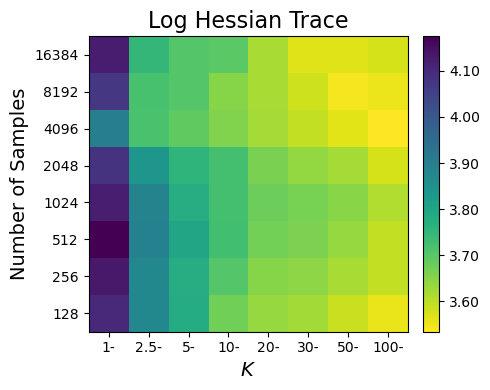

In [56]:
### Plot Sharpness Trace - 8 x 8 grid (Log Scale)
import numpy as np
import matplotlib.pyplot as plt

pde_settings = k_range_list
lr = lr_range[0]

# Create array for sharpness trace values
sharpness_trace_grid = np.array([[0.0 for _ in range(len(pde_settings))] for _ in range(len(sub_sampling_range))])
print(f"Sharpness trace grid shape: {sharpness_trace_grid.shape}")

for k_range in k_ranges:
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    for subsamples in sub_sampling_range:
        if subsamples == 512:
            hyper_setting = f'bsz64_lr{lr}_subsample{subsamples}'
        elif subsamples == 1024:
            hyper_setting = f'bsz32_lr{lr}_subsample{subsamples}'
        elif subsamples == 2048:
            hyper_setting = f'bsz16_lr{lr}_subsample{subsamples}'
        elif subsamples == 4096:
            hyper_setting = f'bsz8_lr{lr}_subsample{subsamples}'
        else:
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        
        trace_val = hessian_stats[pde_setting][hyper_setting]['sharpness_trace_mean']
        # Apply log transform, handle potential zeros
        sharpness_trace_grid[sub_sampling_range.index(subsamples), k_ranges.index(k_range)] = np.log10(trace_val) if trace_val > 0 else 0

fig, ax = plt.subplots(1, 1, figsize=(5, 4))

X, Y = np.meshgrid(np.arange(len(pde_settings)), np.arange(len(sub_sampling_range)))
heatmap = ax.pcolormesh(X, Y, sharpness_trace_grid, cmap='viridis_r', shading='auto', rasterized=True)

ax.set_xticks(np.arange(len(pde_settings)))
ax.set_xticklabels(pde_settings, fontsize=ticks_fontsize)
ax.set_yticks(np.arange(len(sub_sampling_range)))
ax.set_yticklabels(data_number_range, fontsize=ticks_fontsize)

ax.set_xlabel("$K$", fontsize=label_fontsize)
ax.set_ylabel("Number of Samples", fontsize=label_fontsize)
ax.set_title("Log Hessian Trace", fontsize=16)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(heatmap, cax=cax)
cbar.ax.tick_params(labelsize=ticks_fontsize)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(format_colorbar_tick))

plt.tight_layout()
plt.savefig('/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/plots/pdf/sharpness_trace_fno.pdf', bbox_inches='tight')
plt.show()

Sharpness eigenval grid shape: (8, 8)


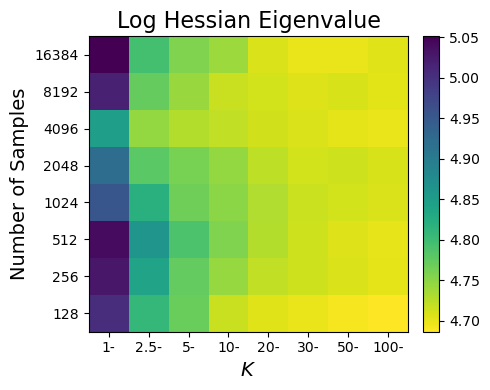

In [57]:
### Plot Sharpness Eigenvalue - 8 x 8 grid (Log Scale)
import numpy as np
import matplotlib.pyplot as plt

pde_settings = k_range_list
lr = lr_range[0]

# Create array for sharpness eigenvalue values
sharpness_eigenval_grid = np.array([[0.0 for _ in range(len(pde_settings))] for _ in range(len(sub_sampling_range))])
print(f"Sharpness eigenval grid shape: {sharpness_eigenval_grid.shape}")

for k_range in k_ranges:
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    for subsamples in sub_sampling_range:
        if subsamples == 512:
            hyper_setting = f'bsz64_lr{lr}_subsample{subsamples}'
        elif subsamples == 1024:
            hyper_setting = f'bsz32_lr{lr}_subsample{subsamples}'
        elif subsamples == 2048:
            hyper_setting = f'bsz16_lr{lr}_subsample{subsamples}'
        elif subsamples == 4096:
            hyper_setting = f'bsz8_lr{lr}_subsample{subsamples}'
        else:
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        
        eigenval = hessian_stats[pde_setting][hyper_setting]['sharpness_eigenval_mean']
        # Apply log transform, handle potential zeros
        sharpness_eigenval_grid[sub_sampling_range.index(subsamples), k_ranges.index(k_range)] = np.log10(eigenval) if eigenval > 0 else 0

fig, ax = plt.subplots(1, 1, figsize=(5, 4))

X, Y = np.meshgrid(np.arange(len(pde_settings)), np.arange(len(sub_sampling_range)))
heatmap = ax.pcolormesh(X, Y, sharpness_eigenval_grid, cmap='viridis_r', shading='auto', rasterized=True)

ax.set_xticks(np.arange(len(pde_settings)))
ax.set_xticklabels(pde_settings, fontsize=ticks_fontsize)
ax.set_yticks(np.arange(len(sub_sampling_range)))
ax.set_yticklabels(data_number_range, fontsize=ticks_fontsize)

ax.set_xlabel("$K$", fontsize=label_fontsize)
ax.set_ylabel("Number of Samples", fontsize=label_fontsize)
ax.set_title("Log Hessian Eigenvalue", fontsize=16)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(heatmap, cax=cax)
cbar.ax.tick_params(labelsize=ticks_fontsize)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(format_colorbar_tick))

plt.tight_layout()
plt.savefig('/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/plots/pdf/sharpness_eigenval_fno.pdf', bbox_inches='tight')
plt.show()

### CKA RBF Analysis

In [58]:
import re
import numpy as np
from itertools import combinations

# Read CKA RBF data
cka_dir = "/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/cka_analysis"
cka_stats = {}

for k_range in k_ranges:
    pde_settings = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    cka_stats[pde_settings] = {}
    
    for subsamples in sub_sampling_range:
        for lr in lr_range:
            if subsamples == 256:
                cka_base_dir = f'{cka_dir}/expts_eps1000'
                bsz_tmp = 128
            elif subsamples == 128:
                cka_base_dir = f'{cka_dir}/expts_eps750'
                bsz_tmp = 128
            elif subsamples == 64:
                cka_base_dir = f'{cka_dir}/expts_eps500'
                bsz_tmp = 128
            elif subsamples == 32:
                cka_base_dir = f'{cka_dir}/expts_eps300'
                bsz_tmp = 128
            elif subsamples == 16:
                cka_base_dir = f'{cka_dir}/expts_eps200'
                bsz_tmp = 128
            elif subsamples == 8:
                cka_base_dir = f'{cka_dir}/expts_eps150'
                bsz_tmp = 128
            elif subsamples == 4:
                cka_base_dir = f'{cka_dir}/expts_eps100'
                bsz_tmp = 128
            elif subsamples == 2:
                cka_base_dir = f'{cka_dir}/expts_eps75'
                bsz_tmp = 128
            else:
                cka_base_dir = f'{cka_dir}/expts_eps1000'
                bsz_tmp = 128

            hyper_settings = f'bsz{bsz_tmp}_lr{lr}_subsample{subsamples}'
            
            cka_stats[pde_settings][hyper_settings] = {}
            cka_scores_list = []
            
            # Generate all pairs of seeds for comparison
            seed_pairs = list(combinations(seed_range, 2))
            
            for seed_a, seed_b in seed_pairs:
                cka_file = f'{cka_base_dir}/{pde_settings}/_vs__rbf/{hyper_settings}/seed{seed_b}_vs_{seed_a}/cka_rbf_results.txt'
                
                try:
                    with open(cka_file, 'r') as f:
                        lines = f.readlines()
                        for line in lines:
                            if line.startswith('cka_score:'):
                                cka_score = float(line.split(':')[1].strip())
                                cka_scores_list.append(cka_score)
                                break
                except Exception as e:
                    # Try the reverse order
                    cka_file = f'{cka_base_dir}/{pde_settings}/_vs__rbf/{hyper_settings}/seed{seed_a}_vs_{seed_b}/cka_rbf_results.txt'
                    try:
                        with open(cka_file, 'r') as f:
                            lines = f.readlines()
                            for line in lines:
                                if line.startswith('cka_score:'):
                                    cka_score = float(line.split(':')[1].strip())
                                    cka_scores_list.append(cka_score)
                                    break
                    except:
                        pass
            
            cka_stats[pde_settings][hyper_settings]['cka_score_mean'] = np.mean(cka_scores_list) if len(cka_scores_list) > 0 else 0.0
            cka_stats[pde_settings][hyper_settings]['cka_score_std'] = np.std(cka_scores_list) if len(cka_scores_list) > 0 else 0.0

print("CKA RBF data loaded successfully!")

CKA RBF data loaded successfully!


CKA score grid shape: (8, 8)


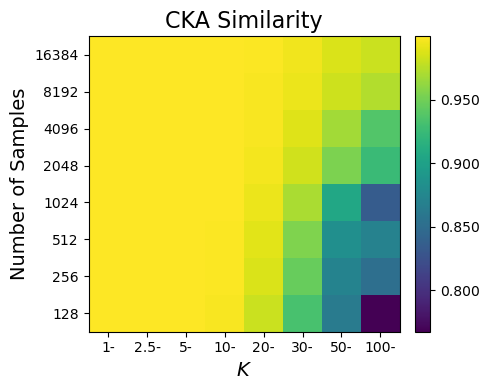

In [59]:
### Plot CKA RBF Score - 8 x 8 grid
import numpy as np
import matplotlib.pyplot as plt

pde_settings = k_range_list
lr = lr_range[0]

# Create array for CKA score values
cka_score_grid = np.array([[0.0 for _ in range(len(pde_settings))] for _ in range(len(sub_sampling_range))])
print(f"CKA score grid shape: {cka_score_grid.shape}")

for k_range in k_ranges:
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    for subsamples in sub_sampling_range:
        if subsamples == 512:
            hyper_setting = f'bsz64_lr{lr}_subsample{subsamples}'
        elif subsamples == 1024:
            hyper_setting = f'bsz32_lr{lr}_subsample{subsamples}'
        elif subsamples == 2048:
            hyper_setting = f'bsz16_lr{lr}_subsample{subsamples}'
        elif subsamples == 4096:
            hyper_setting = f'bsz8_lr{lr}_subsample{subsamples}'
        else:
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        
        cka_score_grid[sub_sampling_range.index(subsamples), k_ranges.index(k_range)] = cka_stats[pde_setting][hyper_setting]['cka_score_mean']

fig, ax = plt.subplots(1, 1, figsize=(5, 4))

X, Y = np.meshgrid(np.arange(len(pde_settings)), np.arange(len(sub_sampling_range)))
# Use 'viridis' (not reversed) so high CKA scores (good) are yellow, low scores are dark
heatmap = ax.pcolormesh(X, Y, cka_score_grid, cmap='viridis', shading='auto', rasterized=True)

ax.set_xticks(np.arange(len(pde_settings)))
ax.set_xticklabels(pde_settings, fontsize=ticks_fontsize)
ax.set_yticks(np.arange(len(sub_sampling_range)))
ax.set_yticklabels(data_number_range, fontsize=ticks_fontsize)

ax.set_xlabel("$K$", fontsize=label_fontsize)
ax.set_ylabel("Number of Samples", fontsize=label_fontsize)
ax.set_title("CKA Similarity", fontsize=16)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(heatmap, cax=cax)
cbar.ax.tick_params(labelsize=ticks_fontsize)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(format_colorbar_tick))

plt.tight_layout()
plt.savefig('/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/plots/pdf/cka_rbf_fno.pdf', bbox_inches='tight')
plt.show()

### Linear Mode Connectivity (LMC) Analysis

In [60]:
import re
import numpy as np
from itertools import combinations

# Read LMC (Linear Mode Connectivity) data
lmc_dir = "/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/mode_connectivity_analysis"
lmc_stats = {}

for k_range in k_ranges:
    pde_settings = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    lmc_stats[pde_settings] = {}
    
    for subsamples in sub_sampling_range:
        for lr in lr_range:
            if subsamples == 256:
                lmc_base_dir = f'{lmc_dir}/expts_eps1000'
                bsz_tmp = 128
            elif subsamples == 128:
                lmc_base_dir = f'{lmc_dir}/expts_eps750'
                bsz_tmp = 128
            elif subsamples == 64:
                lmc_base_dir = f'{lmc_dir}/expts_eps500'
                bsz_tmp = 128
            elif subsamples == 32:
                lmc_base_dir = f'{lmc_dir}/expts_eps300'
                bsz_tmp = 128
            elif subsamples == 16:
                lmc_base_dir = f'{lmc_dir}/expts_eps200'
                bsz_tmp = 128
            elif subsamples == 8:
                lmc_base_dir = f'{lmc_dir}/expts_eps150'
                bsz_tmp = 128
            elif subsamples == 4:
                lmc_base_dir = f'{lmc_dir}/expts_eps100'
                bsz_tmp = 128
            elif subsamples == 2:
                lmc_base_dir = f'{lmc_dir}/expts_eps75'
                bsz_tmp = 128
            else:
                lmc_base_dir = f'{lmc_dir}/expts_eps1000'
                bsz_tmp = 128

            hyper_settings = f'bsz{bsz_tmp}_lr{lr}_subsample{subsamples}'
            
            lmc_stats[pde_settings][hyper_settings] = {}
            mode_connectivity_list = []
            
            # Generate all pairs of seeds for comparison
            seed_pairs = list(combinations(seed_range, 2))
            
            for seed_a, seed_b in seed_pairs:
                lmc_file = f'{lmc_base_dir}/{pde_settings}/_vs__linear/{hyper_settings}/seed{seed_b}_vs_{seed_a}/mode_connectivity_linear_results.txt'
                
                try:
                    with open(lmc_file, 'r') as f:
                        lines = f.readlines()
                        for line in lines:
                            if line.startswith('mode_connectivity:'):
                                mode_conn = float(line.split(':')[1].strip())
                                mode_connectivity_list.append(mode_conn)
                                break
                except Exception as e:
                    # Try the reverse order
                    lmc_file = f'{lmc_base_dir}/{pde_settings}/_vs__linear/{hyper_settings}/seed{seed_a}_vs_{seed_b}/mode_connectivity_linear_results.txt'
                    try:
                        with open(lmc_file, 'r') as f:
                            lines = f.readlines()
                            for line in lines:
                                if line.startswith('mode_connectivity:'):
                                    mode_conn = float(line.split(':')[1].strip())
                                    mode_connectivity_list.append(mode_conn)
                                    break
                    except:
                        pass
            
            lmc_stats[pde_settings][hyper_settings]['mode_connectivity_mean'] = np.mean(mode_connectivity_list) if len(mode_connectivity_list) > 0 else 0.0
            lmc_stats[pde_settings][hyper_settings]['mode_connectivity_std'] = np.std(mode_connectivity_list) if len(mode_connectivity_list) > 0 else 0.0

print("LMC data loaded successfully!")

LMC data loaded successfully!


LMC grid shape: (8, 8)


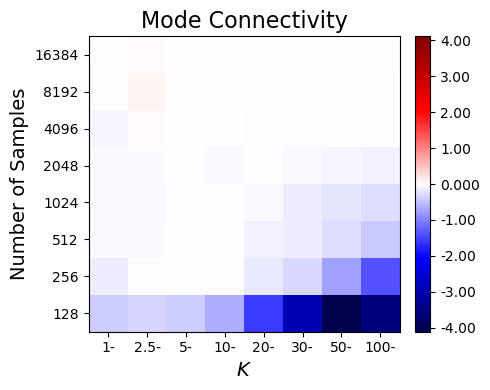

In [61]:
### Plot LMC (Mode Connectivity) - 8 x 8 grid
import numpy as np
import matplotlib.pyplot as plt

pde_settings = k_range_list
lr = lr_range[0]

# Create array for mode connectivity values
lmc_grid = np.array([[0.0 for _ in range(len(pde_settings))] for _ in range(len(sub_sampling_range))])
print(f"LMC grid shape: {lmc_grid.shape}")

for k_range in k_ranges:
    pde_setting = f'poisson_scale_k{k_range[0]}_{k_range[1]}_val1024_1M'
    for subsamples in sub_sampling_range:
        if subsamples == 512:
            hyper_setting = f'bsz64_lr{lr}_subsample{subsamples}'
        elif subsamples == 1024:
            hyper_setting = f'bsz32_lr{lr}_subsample{subsamples}'
        elif subsamples == 2048:
            hyper_setting = f'bsz16_lr{lr}_subsample{subsamples}'
        elif subsamples == 4096:
            hyper_setting = f'bsz8_lr{lr}_subsample{subsamples}'
        else:
            hyper_setting = f'bsz{bsz}_lr{lr}_subsample{subsamples}'
        
        lmc_grid[sub_sampling_range.index(subsamples), k_ranges.index(k_range)] = lmc_stats[pde_setting][hyper_setting]['mode_connectivity_mean']

fig, ax = plt.subplots(1, 1, figsize=(5, 4))

X, Y = np.meshgrid(np.arange(len(pde_settings)), np.arange(len(sub_sampling_range)))
# Use seismic colormap: negative (good connectivity) = red, ~0 = white, positive (poor connectivity) = blue
vmax = max(abs(np.nanmin(lmc_grid)), abs(np.nanmax(lmc_grid)))
heatmap = ax.pcolormesh(X, Y, lmc_grid, cmap='seismic', shading='auto', rasterized=True,
                        vmin=-vmax, vmax=vmax)

ax.set_xticks(np.arange(len(pde_settings)))
ax.set_xticklabels(pde_settings, fontsize=ticks_fontsize)
ax.set_yticks(np.arange(len(sub_sampling_range)))
ax.set_yticklabels(data_number_range, fontsize=ticks_fontsize)

ax.set_xlabel("$K$", fontsize=label_fontsize)
ax.set_ylabel("Number of Samples", fontsize=label_fontsize)
ax.set_title("Mode Connectivity", fontsize=16)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(heatmap, cax=cax)
cbar.ax.tick_params(labelsize=ticks_fontsize)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(format_colorbar_tick))

plt.tight_layout()
plt.savefig('/jumbo/yaoqingyang/yuanzhehu/neuraloperators-TL-scaling/plots/pdf/lmc_linear_fno.pdf', bbox_inches='tight')
plt.show()